# Data Cleaning & Preparation

Decisions made here are grounded in `data_findings.md`. Each step references the specific finding that justifies it.

**Output files produced:**
- `processed/X_train.csv` — engineered + scaled training features
- `processed/X_test.csv` — same pipeline applied to test
- `processed/y_train.csv` — raw target (full)
- `processed/y_train_winsorized.csv` — target clipped at 1st–99th percentile (for outlier-robust training)
- `processed/feature_names.txt` — ordered list of all feature column names

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

os.makedirs("processed", exist_ok=True)

train = pd.read_csv("spring2026_kaggle_linear_regression_challenge_train.csv")
test  = pd.read_csv("spring2026_kaggle_linear_regression_challenge_test.csv")

BASE_FEATURES = [c for c in train.columns if c.startswith("x")]

X_raw   = train[BASE_FEATURES].copy()
y_raw   = train["target"].copy()
Xt_raw  = test[BASE_FEATURES].copy()
train_ids = train["Id"]
test_ids  = test["Id"]

print(f"Train: {X_raw.shape}  |  Test: {Xt_raw.shape}")
print(f"Base features: {BASE_FEATURES}")

Train: (2500, 15)  |  Test: (2500, 15)
Base features: ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14']


## Step 1 · Imputation

**Finding:** Every feature has 0.9–1.5% missing values (train) and 1.1–1.9% (test). The co-occurrence heatmap showed a maximum of 7 rows with any two features simultaneously missing, consistent with MCAR (Missing Completely At Random). Median imputation is appropriate.

**Rule:** Fit the imputer **only on train**, then transform both train and test. Using test data to fit would leak test distribution into the pipeline.

In [2]:
imputer = SimpleImputer(strategy="median")
imputer.fit(X_raw)

X_imp  = pd.DataFrame(imputer.transform(X_raw),  columns=BASE_FEATURES, index=X_raw.index)
Xt_imp = pd.DataFrame(imputer.transform(Xt_raw), columns=BASE_FEATURES, index=Xt_raw.index)

# Verify: no missing values remain
assert X_imp.isnull().sum().sum() == 0,  "Missing values remain in train after imputation"
assert Xt_imp.isnull().sum().sum() == 0, "Missing values remain in test after imputation"

print("Train medians used for imputation:")
for f, med in zip(BASE_FEATURES, imputer.statistics_):
    print(f"  {f:4s}: {med:.4f}")
print(f"\nAll missing values filled. Train shape: {X_imp.shape}  Test shape: {Xt_imp.shape}")

Train medians used for imputation:
  x0  : -0.0272
  x1  : 0.0642
  x2  : 0.0449
  x3  : -0.0540
  x4  : -0.4740
  x5  : -0.9602
  x6  : 0.0139
  x7  : 0.1871
  x8  : 0.1273
  x9  : -0.2509
  x10 : -0.1204
  x11 : -0.5879
  x12 : -0.0412
  x13 : 0.2005
  x14 : 0.0683

All missing values filled. Train shape: (2500, 15)  Test shape: (2500, 15)


## Step 2 · Target Preparation

**Finding:** The target has skewness=13.59 and kurtosis=708. 84 rows (3.36%) have |target| > 1,000 and 24 rows (0.96%) have |target| > 5,000. These extreme values dominate squared-error loss.

We produce **two target versions** and save both:
- `y_raw` — the original target, for models that handle heavy tails (Huber, tree ensembles)
- `y_winsorized` — clipped at the 1st and 99th percentile, for OLS-style models where outlier rows would otherwise dominate training

We also attach an `is_extreme` flag (|target| > 1,000) that can be used as a sample weight or for diagnostic filtering.

In [3]:
p01 = y_raw.quantile(0.01)
p99 = y_raw.quantile(0.99)

y_winsorized = y_raw.clip(lower=p01, upper=p99)
is_extreme   = (y_raw.abs() > 1000).astype(int)

print(f"Winsorization bounds: [{p01:.2f}, {p99:.2f}]")
print(f"Rows clipped: {(y_raw < p01).sum()} low, {(y_raw > p99).sum()} high")
print(f"is_extreme==1: {is_extreme.sum()} rows ({is_extreme.mean()*100:.2f}%)")
print()
print("y_raw       — mean={:.2f}  std={:.2f}  skew={:.2f}".format(
    y_raw.mean(), y_raw.std(), y_raw.skew()))
print("y_winsorized — mean={:.2f}  std={:.2f}  skew={:.2f}".format(
    y_winsorized.mean(), y_winsorized.std(), y_winsorized.skew()))

Winsorization bounds: [-2654.94, 1591.06]
Rows clipped: 25 low, 25 high
is_extreme==1: 84 rows (3.36%)

y_raw       — mean=-22.04  std=1978.18  skew=13.59
y_winsorized — mean=-20.81  std=374.70  skew=-3.48


## Step 3 · Feature Engineering

**Findings driving this step:**

| Feature | r with target | Justification |
|---|---|---|
| x9 (raw) | 0.232 | Dominant linear signal |
| x9² | 0.049 | x9–target relationship has diminishing returns above Q3 |
| x9 × x11 | 0.160 | Strongest pairwise interaction found |
| x9 × x12 | 0.105 | Second strongest |
| x9 × x2 | −0.105 | Third strongest |
| x9 × x0 | −0.092 | |
| x9 × x8 | −0.090 | |
| x9 × x5 | 0.089 | |
| x9 × x1 | 0.085 | All above threshold \|r\| > 0.08 |
| x9 × x10 | −0.049 | Marginal but above noise floor |
| x9 × x3 | −0.048 | Marginal but above noise floor |
| x11 × x7 | 0.066 | x11 is a hidden amplifier (3rd in top interactions) |
| x11 × x1 | 0.054 | |
| x11 × x12 | 0.047 | |

**Not included:** x9 interactions with x14, x13, x4, x6, x7 (all |r| < 0.02 — indistinguishable from noise).

In [4]:
def engineer_features(df):
    out = df.copy()

    # x9 non-linearity (diminishing returns above Q3 observed in conditional median plot)
    out["x9_sq"] = df["x9"] ** 2

    # x9 interactions — only those with |r| > 0.04 with target (from EDA)
    for col in ["x11", "x12", "x2", "x0", "x8", "x5", "x1", "x10", "x3"]:
        out[f"x9_x_{col}"] = df["x9"] * df[col]

    # x11 interactions — x11 is a hidden amplifier (appears in 3 top interactions)
    for col in ["x7", "x1", "x12"]:
        out[f"x11_x_{col}"] = df["x11"] * df[col]

    return out


X_eng  = engineer_features(X_imp)
Xt_eng = engineer_features(Xt_imp)

engineered_cols = [c for c in X_eng.columns if c not in BASE_FEATURES]
print(f"Base features    : {len(BASE_FEATURES)}")
print(f"Engineered features: {len(engineered_cols)}")
print(f"Total features   : {X_eng.shape[1]}")
print()
print("New columns:", engineered_cols)

# Sanity-check correlations of new features against target
print("\nCorrelation of engineered features with raw target:")
for col in engineered_cols:
    r = X_eng[col].corr(y_raw)
    print(f"  {col:20s}: r={r:+.5f}")

Base features    : 15
Engineered features: 13
Total features   : 28

New columns: ['x9_sq', 'x9_x_x11', 'x9_x_x12', 'x9_x_x2', 'x9_x_x0', 'x9_x_x8', 'x9_x_x5', 'x9_x_x1', 'x9_x_x10', 'x9_x_x3', 'x11_x_x7', 'x11_x_x1', 'x11_x_x12']

Correlation of engineered features with raw target:
  x9_sq               : r=+0.04863
  x9_x_x11            : r=+0.15987
  x9_x_x12            : r=+0.10535
  x9_x_x2             : r=-0.10517
  x9_x_x0             : r=-0.09174
  x9_x_x8             : r=-0.08984
  x9_x_x5             : r=+0.08892
  x9_x_x1             : r=+0.08492
  x9_x_x10            : r=-0.04888
  x9_x_x3             : r=-0.04757
  x11_x_x7            : r=+0.06643
  x11_x_x1            : r=+0.05434
  x11_x_x12           : r=+0.04677


## Step 4 · Scaling

**Finding:** Features have different ranges (e.g., x3 std≈2.0, x4 std≈12.8, x5 std≈15.2). Engineered interaction features will have even larger ranges (products of two features). StandardScaler brings everything to zero mean and unit variance, which is required for any regularised linear model (Ridge, Lasso, ElasticNet) and beneficial for distance-based models.

Tree-based models (Random Forest, XGBoost, LightGBM) are scale-invariant, but applying the scaler doesn't hurt them and keeps a single, consistent pipeline.

**Rule:** Fit scaler **only on train**, transform both.

In [5]:
all_feature_names = list(X_eng.columns)

scaler = StandardScaler()
scaler.fit(X_eng)

X_scaled  = pd.DataFrame(scaler.transform(X_eng),  columns=all_feature_names, index=X_eng.index)
Xt_scaled = pd.DataFrame(scaler.transform(Xt_eng), columns=all_feature_names, index=Xt_eng.index)

print("Feature means after scaling (should be ~0):")
print(X_scaled.mean().round(6).to_string())
print()
print("Feature stds after scaling (should be ~1):")
print(X_scaled.std().round(6).to_string())

Feature means after scaling (should be ~0):
x0          -0.0
x1           0.0
x2          -0.0
x3           0.0
x4           0.0
x5          -0.0
x6          -0.0
x7           0.0
x8          -0.0
x9          -0.0
x10          0.0
x11         -0.0
x12         -0.0
x13          0.0
x14          0.0
x9_sq        0.0
x9_x_x11    -0.0
x9_x_x12    -0.0
x9_x_x2      0.0
x9_x_x0     -0.0
x9_x_x8      0.0
x9_x_x5      0.0
x9_x_x1     -0.0
x9_x_x10     0.0
x9_x_x3      0.0
x11_x_x7    -0.0
x11_x_x1     0.0
x11_x_x12    0.0

Feature stds after scaling (should be ~1):
x0           1.0002
x1           1.0002
x2           1.0002
x3           1.0002
x4           1.0002
x5           1.0002
x6           1.0002
x7           1.0002
x8           1.0002
x9           1.0002
x10          1.0002
x11          1.0002
x12          1.0002
x13          1.0002
x14          1.0002
x9_sq        1.0002
x9_x_x11     1.0002
x9_x_x12     1.0002
x9_x_x2      1.0002
x9_x_x0      1.0002
x9_x_x8      1.0002
x9_x_x5      1.0

## Step 5 · Final Validation

Before saving, run a set of checks to confirm the pipeline produced clean, consistent outputs.

Check                                Pass  Value
X_train shape                          OK  (2500, 28)
X_test shape                           OK  (2500, 28)
No NaN in X_train                      OK  0
No NaN in X_test                       OK  0
No Inf in X_train                      OK  all finite
No Inf in X_test                       OK  all finite
Same columns train/test                OK  match
y_raw length                           OK  2500
y_winsorized length                    OK  2500
is_extreme length                      OK  2500
y_win min >= p01                       OK  -2654.94
y_win max <= p99                       OK  1591.06
ALL CHECKS PASSED


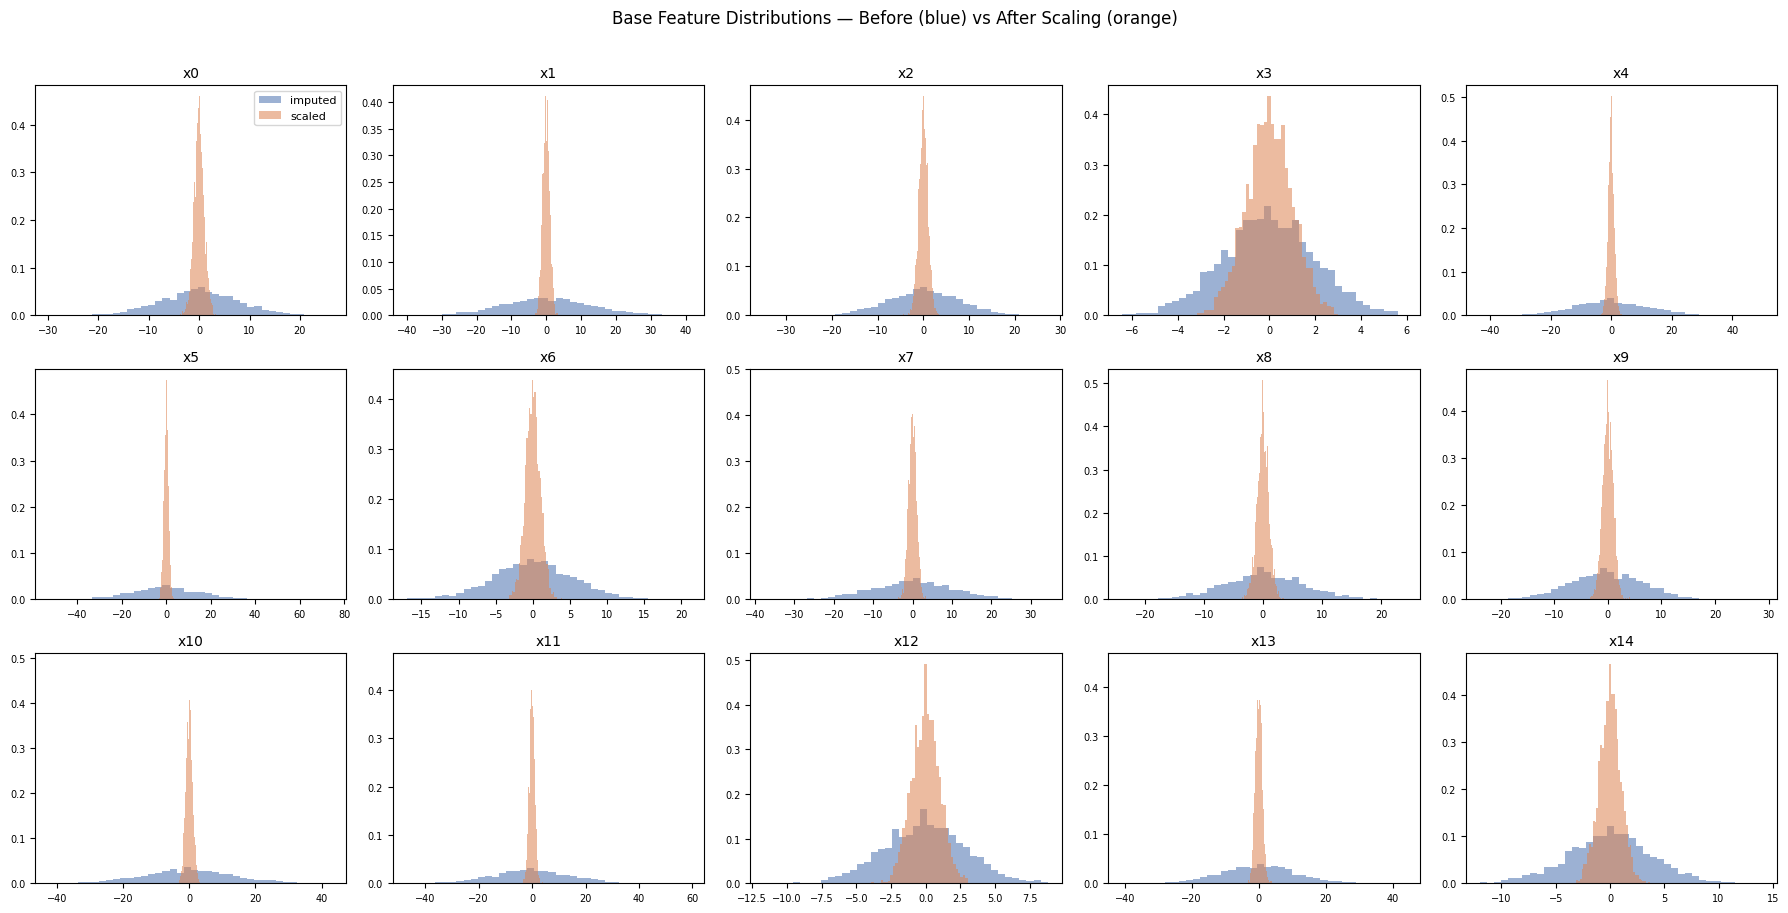

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

checks = []

# Shape
checks.append(("X_train shape", X_scaled.shape == (2500, len(all_feature_names)), str(X_scaled.shape)))
checks.append(("X_test shape",  Xt_scaled.shape == (2500, len(all_feature_names)), str(Xt_scaled.shape)))

# No NaNs
checks.append(("No NaN in X_train", X_scaled.isnull().sum().sum() == 0, "0"))
checks.append(("No NaN in X_test",  Xt_scaled.isnull().sum().sum() == 0, "0"))

# No infinite values
checks.append(("No Inf in X_train", np.isfinite(X_scaled.values).all(), "all finite"))
checks.append(("No Inf in X_test",  np.isfinite(Xt_scaled.values).all(), "all finite"))

# Column consistency
checks.append(("Same columns train/test", list(X_scaled.columns) == list(Xt_scaled.columns), "match"))

# Target sizes
checks.append(("y_raw length",        len(y_raw) == 2500, str(len(y_raw))))
checks.append(("y_winsorized length", len(y_winsorized) == 2500, str(len(y_winsorized))))
checks.append(("is_extreme length",   len(is_extreme) == 2500, str(len(is_extreme))))

# y_winsorized truly clipped
checks.append(("y_win min >= p01", float(y_winsorized.min()) >= p01, f"{y_winsorized.min():.2f}"))
checks.append(("y_win max <= p99", float(y_winsorized.max()) <= p99, f"{y_winsorized.max():.2f}"))

print("=" * 55)
print(f"{'Check':<35} {'Pass':>5}  {'Value'}")
print("=" * 55)
all_pass = True
for name, ok, val in checks:
    status = " OK" if ok else "FAIL"
    if not ok:
        all_pass = False
    print(f"{name:<35} {status:>5}  {val}")
print("=" * 55)
print("ALL CHECKS PASSED" if all_pass else "SOME CHECKS FAILED — review above")

# Distribution comparison: base features, pre- vs post-scaling (train only)
fig, axes = plt.subplots(3, 5, figsize=(18, 9))
for ax, feat in zip(axes.flat, BASE_FEATURES):
    ax.hist(X_imp[feat],    bins=40, alpha=0.55, density=True, color="#4C72B0", label="imputed")
    ax.hist(X_scaled[feat], bins=40, alpha=0.55, density=True, color="#DD8452", label="scaled")
    ax.set_title(feat, fontsize=10)
    ax.tick_params(labelsize=7)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Base Feature Distributions — Before (blue) vs After Scaling (orange)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Step 6 · Save Outputs

All outputs go into `processed/`. The modeling notebook should load from here — never re-run this pipeline mid-experiment, as it would refit the scaler and imputer on a different random state if the data changes.

In [7]:
import joblib

# ── Feature matrices ──────────────────────────────────────────────────────────
X_scaled.to_csv("processed/X_train.csv", index=False)
Xt_scaled.to_csv("processed/X_test.csv",  index=False)

# ── Target vectors ────────────────────────────────────────────────────────────
y_raw.to_csv("processed/y_train.csv", header=True, index=False)
y_winsorized.to_csv("processed/y_train_winsorized.csv", header=True, index=False)
is_extreme.to_csv("processed/is_extreme.csv", header=True, index=False)

# ── IDs (for submission alignment) ───────────────────────────────────────────
train_ids.to_csv("processed/train_ids.csv", index=False)
test_ids.to_csv("processed/test_ids.csv",   index=False)

# ── Feature name registry ─────────────────────────────────────────────────────
with open("processed/feature_names.txt", "w") as f:
    f.write("\n".join(all_feature_names))

# ── Fitted transformers (for reproducibility) ─────────────────────────────────
joblib.dump(imputer, "processed/imputer.joblib")
joblib.dump(scaler,  "processed/scaler.joblib")

# ── Summary ───────────────────────────────────────────────────────────────────
print("Saved to processed/:")
for fname in sorted(os.listdir("processed")):
    path = os.path.join("processed", fname)
    size = os.path.getsize(path)
    print(f"  {fname:<35} {size/1024:>7.1f} KB")

print()
print(f"Final feature count : {len(all_feature_names)}")
print(f"  Base features     : {len(BASE_FEATURES)}")
print(f"  Engineered        : {len(engineered_cols)}")
print()
print("Feature list:")
for i, name in enumerate(all_feature_names, 1):
    tag = "(engineered)" if name in engineered_cols else ""
    print(f"  {i:2d}. {name:<20} {tag}")

Saved to processed/:
  X_test.csv                           1353.3 KB
  X_train.csv                          1352.5 KB
  feature_names.txt                       0.2 KB
  imputer.joblib                          1.0 KB
  is_extreme.csv                          4.9 KB
  scaler.joblib                           1.9 KB
  test_ids.csv                           11.7 KB
  train_ids.csv                          11.7 KB
  y_train.csv                            45.9 KB
  y_train_winsorized.csv                 45.9 KB

Final feature count : 28
  Base features     : 15
  Engineered        : 13

Feature list:
   1. x0                   
   2. x1                   
   3. x2                   
   4. x3                   
   5. x4                   
   6. x5                   
   7. x6                   
   8. x7                   
   9. x8                   
  10. x9                   
  11. x10                  
  12. x11                  
  13. x12                  
  14. x13                  
  15. 

## Loading in the Modeling Notebook

Paste this block at the top of any modeling notebook to load the prepared data:

```python
import pandas as pd
import numpy as np

X_train = pd.read_csv("processed/X_train.csv")
X_test  = pd.read_csv("processed/X_test.csv")
y       = pd.read_csv("processed/y_train.csv").squeeze()
y_wins  = pd.read_csv("processed/y_train_winsorized.csv").squeeze()
is_ext  = pd.read_csv("processed/is_extreme.csv").squeeze().astype(bool)
test_ids = pd.read_csv("processed/test_ids.csv").squeeze()
```

**Which target to use:**
- `y` (raw) → Huber regression, tree ensembles (they are robust to outliers by splitting)
- `y_wins` (winsorized) → Ridge, Lasso, ElasticNet, plain OLS (avoids squared-error dominance by outliers)

**Submission template:**
```python
preds = model.predict(X_test)
submission = pd.DataFrame({"Id": test_ids, "target": preds})
submission.to_csv("submission.csv", index=False)
```